# Day 4 Deep Learning

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy pandas matplotlib tensorflow scikit-learn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

In [ ]:
df= pd.read_excel('/content/drive/MyDrive/AI ML/green skill (24-29)/predict_energy_consumption[1].xlsx')
df.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013258,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [ ]:
df.describe()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.256414,50.421038,10.048115,541.337543,272.347395
std,7.303434,17.531394,5.813484,257.840410,129.064474
min,15.115801,20.193096,0.000233,100.588052,50.013823
25%,20.899332,34.464456,5.227020,317.710693,160.238303
50%,27.420184,51.124034,10.012278,535.851355,272.569144
75%,33.607990,65.627903,15.182071,763.786729,382.997053
max,39.992942,79.964824,19.956417,999.601933,498.987225


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         1000 non-null   float64
 1   humidity            1000 non-null   float64
 2   wind_speed          1000 non-null   float64
 3   solar_irradiance    1000 non-null   float64
 4   energy_consumption  1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


In [ ]:
df.shape

(1000, 5)

In [ ]:
df.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

## Training and Testing

In [ ]:
X = df[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = df['energy_consumption'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Creation


In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse',metrics=['mae'])

In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 87159.8672 - mae: 265.8085 - val_loss: 83603.9219 - val_mae: 258.8264
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87113.3281 - mae: 266.2535 - val_loss: 82987.5781 - val_mae: 257.6271
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 91590.9453 - mae: 273.7414 - val_loss: 81997.1797 - val_mae: 255.6881
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 86331.0625 - mae: 262.2526 - val_loss: 80449.7344 - val_mae: 252.6247
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 88589.4453 - mae: 268.8934 - val_loss: 78136.6250 - val_mae: 247.9725
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 82665.6250 - mae: 256.4637 - val_loss: 74947.1094 - val_mae: 241.4101
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 76990.0234 - mae: 245.2291 - val_loss: 70655.7422 - val_mae: 232.2663
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 72093.9375 - mae: 236.6269 - val_loss: 65

In [ ]:
test_loss,test_mae = model.evaluate(X_test,y_test,verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18026.1230 - mae: 115.5468  
Test Loss: 18073.4648
Test MAE: 115.9543


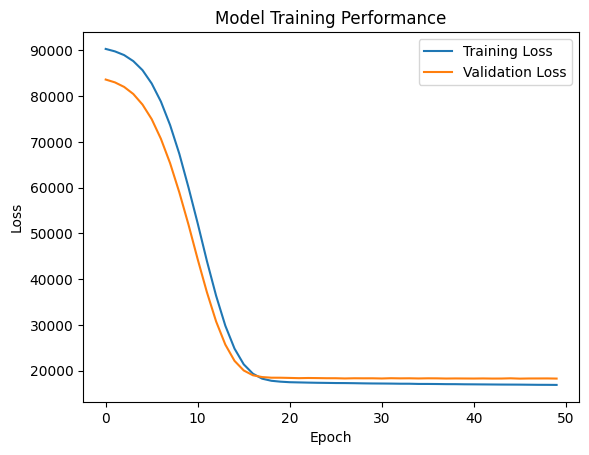

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[284.6936 ],
       [246.21788],
       [258.91205],
       [209.68361],
       [346.99734],
       [314.98395],
       [318.1336 ],
       [285.31326],
       [286.46033],
       [282.02252],
       [241.45587],
       [264.7575 ],
       [277.0561 ],
       [238.97702],
       [296.77063],
       [308.41943],
       [263.4536 ],
       [308.06583],
       [298.1223 ],
       [249.09741],
       [281.27124],
       [278.57535],
       [291.1891 ],
       [281.83942],
       [249.50967],
       [240.08948],
       [260.41034],
       [310.02863],
       [309.10858],
       [262.29993],
       [231.78856],
       [310.21747],
       [301.6269 ],
       [277.0614 ],
       [312.20438],
       [291.20367],
       [218.07822],
       [262.63104],
       [294.16833],
       [236.9642 ],
       [247.51157],
       [242.51634],
       [253.40286],
       [260.30984],
       [264.6514 ],
       [257.58087],
       [263.9026 ],
       [254.61035],
       [285.68112],
       [298.83408],


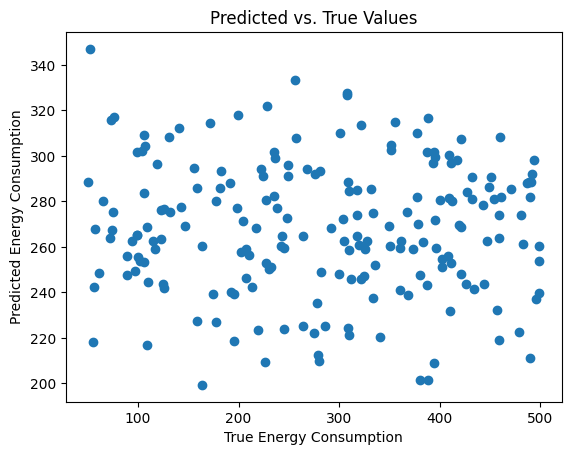

In [ ]:
plt.scatter(y_test, predictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Predicted vs. True Values')
plt.show()